# EDA – Датасет туров (tours.json)

**Цель:** разобраться в структуре данных, найти проблемы и сформулировать выводы для построения модели рекомендаций.

**Данные:** синтетический датасет туров, сгенерированный скриптом `data/generate_tours.py` (200 туров, 10 городов).

---
## 1. Загрузка данных

In [39]:
import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("../data/tours.json")
ARTIFACTS = Path("../artifacts/exp01")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

In [40]:
with open(DATA_PATH, encoding="utf-8") as f:
    tours_raw = json.load(f)

df = pd.DataFrame(tours_raw)
df["start_date"] = pd.to_datetime(df["start_date"])

print(f"Загружено туров: {len(df)}")
df.head(3)

Загружено туров: 200


,id,name,description,city_id,city_name,country,hotel_id,hotel_name,hotel_stars,price,duration_nights,meal_type,start_date,category,photo_url,status
0,362b3800-ccd0-47d2-b8cc-158bd0d22742,Comfort Istanbul — 8 nights,Стамбул — город на стыке двух миров — откроетс...,istanbul,Istanbul,Turkey,novotel_ist,Novotel Istanbul,4,1049.87,8,all_inclusive,2026-08-29,comfort,https://picsum.photos/seed/5579/800/600,active
1,85557a31-8f84-459f-89cf-5ddccdef0590,Standard New York — 11 nights,Одиннадцать ночей в самом сердце Нью-Йорка — э...,new_york,New York,USA,citizenm_nyc,citizenM New York,4,2744.72,11,none,2025-06-17,comfort,https://picsum.photos/seed/8841/800/600,active
2,2f1de70e-2b56-4e38-80d2-af9aaf2edb17,Budget Bali — 14 nights,Две недели на Бали по доступной цене — реально...,bali,Bali,Indonesia,ibis_bali,ibis Styles Bali,3,1564.80,14,all_inclusive,2025-08-11,budget,https://picsum.photos/seed/6900/800/600,active


In [41]:
active = df[df["status"] == "active"]
print(f"Активных туров: {len(active)} из {len(df)} ({len(active)/len(df)*100:.0f}%)")

Активных туров: 170 из 200 (85%)


**Наблюдение:** датасет содержит 200 туров. Каждый тур описывается 16 полями: идентификаторы, гео-данные, характеристики отеля, цена, длительность, питание и статус активности.

---
## 2. Первичный осмотр

In [42]:
print(f"Размер: {df.shape} \n")
print(f"Полных дублей строк: {df.duplicated().sum()}")
df.info()

Размер: (200, 16) 

Полных дублей строк: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               200 non-null    object        
 1   name             200 non-null    object        
 2   description      200 non-null    object        
 3   city_id          200 non-null    object        
 4   city_name        200 non-null    object        
 5   country          200 non-null    object        
 6   hotel_id         200 non-null    object        
 7   hotel_name       200 non-null    object        
 8   hotel_stars      200 non-null    int64         
 9   price            200 non-null    float64       
 10  duration_nights  200 non-null    int64         
 11  meal_type        200 non-null    object        
 12  start_date       200 non-null    datetime64[ns]
 13  category         200 non-null    object        
 14 

In [43]:
df.describe()

,hotel_stars,price,duration_nights,start_date
count,200.000000,200.00000,200.000000,200
mean,4.295000,3398.59300,8.905000,2025-11-02 11:09:36
min,2.000000,352.89000,3.000000,2025-01-02 00:00:00
25%,4.000000,1229.03750,7.000000,2025-05-30 18:00:00
50%,5.000000,1836.78000,9.000000,2025-09-25 12:00:00
75%,5.000000,4229.04750,11.000000,2026-04-03 00:00:00
max,5.000000,13992.18000,14.000000,2026-12-29 00:00:00
std,0.884242,3194.89858,2.681778,NaN


In [44]:
df.describe(include="object")

,id,name,description,city_id,city_name,country,hotel_id,hotel_name,meal_type,category,photo_url,status
count,200,200,200,200,200,200,200,200,200,200,200,200
unique,200,177,200,10,10,10,43,43,3,3,10,2
top,362b3800-ccd0-47d2-b8cc-158bd0d22742,Standard Istanbul — 8 nights,Стамбул — город на стыке двух миров — откроетс...,barcelona,Barcelona,Spain,novotel_ist,Novotel Istanbul,breakfast,luxury,https://picsum.photos/seed/9657/800/600,active
freq,1,4,1,27,27,27,8,8,83,100,27,170


**Наблюдения:**
- Числовые: цена варьируется широко (от ~€353 до ~€14 000), средняя длительность ~9 ночей, звёздность от 2 до 5.
- Категориальные: 10 уникальных городов, 3 типа питания (`all_inclusive`, `breakfast`, `none`), 3 категории тура (`luxury`, `comfort`, `budget`).
- Дата начала тура охватывает 2025–2026 годы.

---
## 3. Распределения ключевых признаков

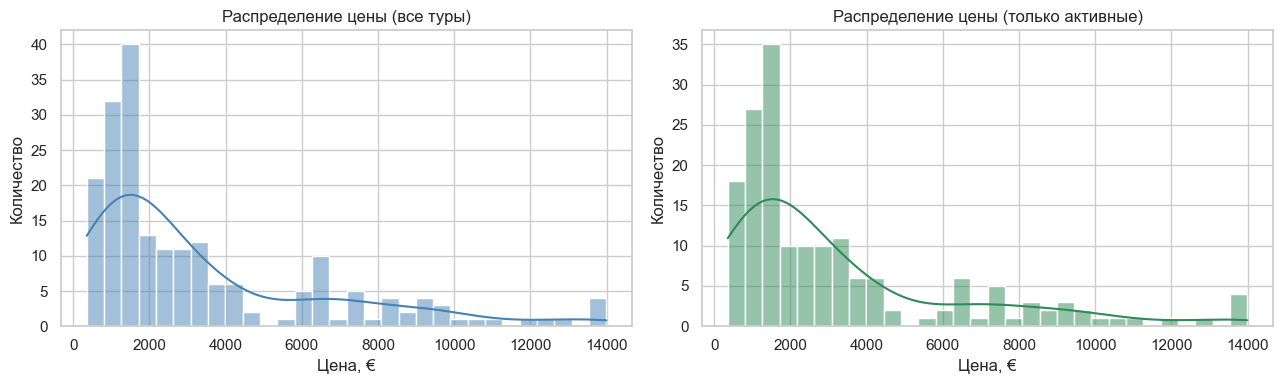

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение цены (все туры)")
axes[0].set_xlabel("Цена, €")
axes[0].set_ylabel("Количество")

sns.histplot(active["price"], bins=30, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Распределение цены (только активные)")
axes[1].set_xlabel("Цена, €")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig(ARTIFACTS / "01_price_distribution.png")
plt.show()

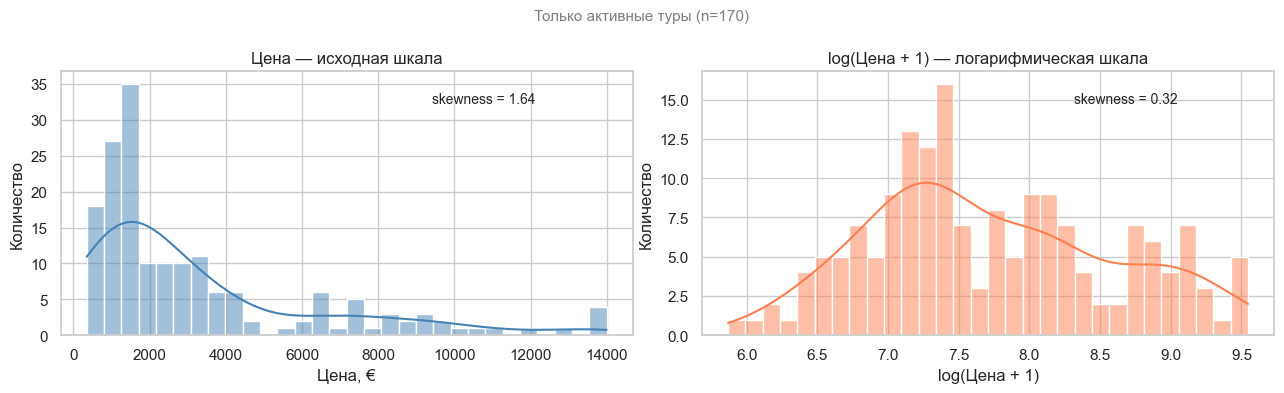

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Только активные туры (n=170)", fontsize=11, color="grey")

sns.histplot(active["price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Цена — исходная шкала")
axes[0].set_xlabel("Цена, €")
axes[0].set_ylabel("Количество")
axes[0].annotate(f"skewness = {active['price'].skew():.2f}", xy=(0.65, 0.88),
                 xycoords="axes fraction", fontsize=10)

sns.histplot(np.log1p(active["price"]), bins=30, kde=True, ax=axes[1], color="coral")
axes[1].set_title("log(Цена + 1) — логарифмическая шкала")
axes[1].set_xlabel("log(Цена + 1)")
axes[1].set_ylabel("Количество")
axes[1].annotate(f"skewness = {np.log1p(active['price']).skew():.2f}", xy=(0.65, 0.88),
                 xycoords="axes fraction", fontsize=10)

plt.tight_layout()
plt.savefig(ARTIFACTS / "02_log_price.png")
plt.show()

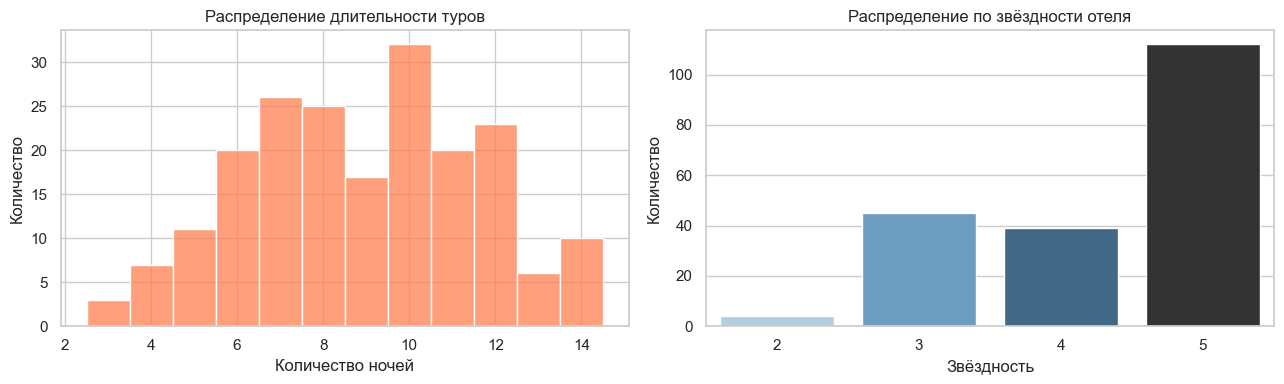

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["duration_nights"], bins=15, ax=axes[0], color="coral", discrete=True)
axes[0].set_title("Распределение длительности туров")
axes[0].set_xlabel("Количество ночей")
axes[0].set_ylabel("Количество")

sns.countplot(x="hotel_stars", hue="hotel_stars", data=df, ax=axes[1],
              palette="Blues_d", legend=False)
axes[1].set_title("Распределение по звёздности отеля")
axes[1].set_xlabel("Звёздность")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig(ARTIFACTS / "03_duration_stars.png")
plt.show()

### Сезонность

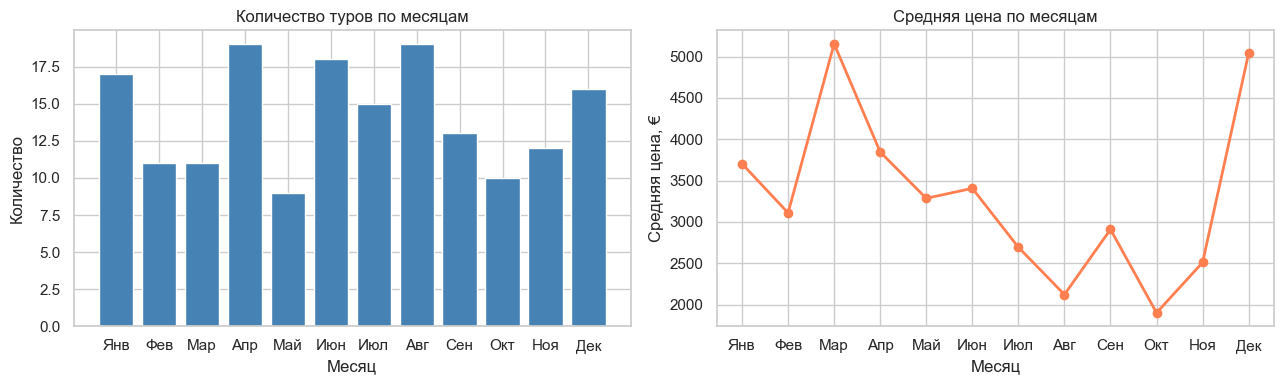

In [48]:
month_names = ["Янв","Фев","Мар","Апр","Май","Июн","Июл","Авг","Сен","Окт","Ноя","Дек"]

monthly = (
    active
    .assign(month=active["start_date"].dt.month)
    .groupby("month")
    .agg(count=("id", "count"), avg_price=("price", "mean"))
    .round(0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(monthly.index, monthly["count"], color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title("Количество туров по месяцам")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Количество")

axes[1].plot(monthly.index, monthly["avg_price"], marker="o", color="coral", linewidth=2)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title("Средняя цена по месяцам")
axes[1].set_xlabel("Месяц")
axes[1].set_ylabel("Средняя цена, €")

plt.tight_layout()
plt.savefig(ARTIFACTS / "04_seasonality.png")
plt.show()

**Наблюдения по сезонности:**
- Распределение туров по месяцам неравномерно: пики количества — **апрель** и **август** (~19 туров), провалы — май и октябрь (~9–10 туров).
- Средняя цена **не коррелирует** с количеством туров: дорогие месяцы — март и декабрь (~€5 000–5 200), а летние месяцы (июль–сентябрь) — самые дешёвые (~€2 000–3 000).
- `start_date` не используется как признак модели: в content-based подходе без пользовательских предпочтений дата не несёт сигнала схожести. Потенциальное использование — жёсткий фильтр по доступным датам на уровне сервиса.

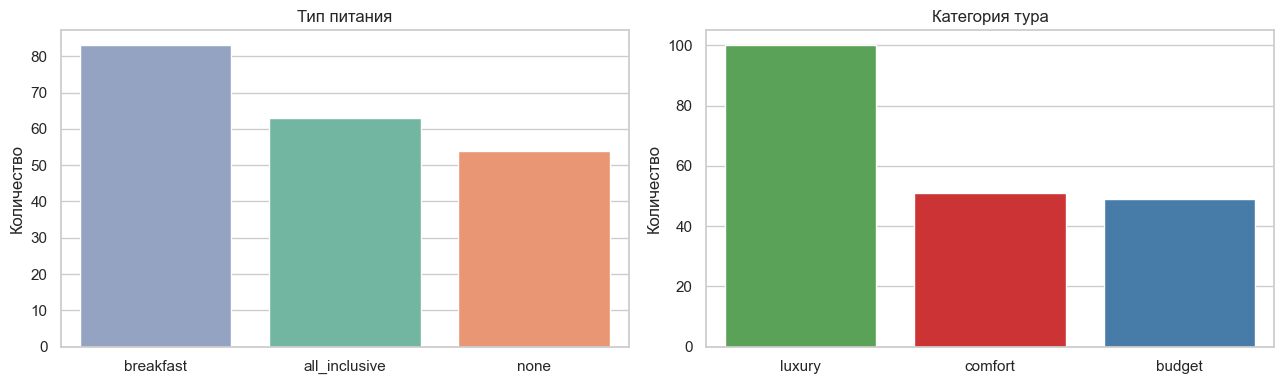

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

meal_order = df["meal_type"].value_counts().index
sns.countplot(x="meal_type", hue="meal_type", data=df, order=meal_order,
              ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Тип питания")
axes[0].set_xlabel("")
axes[0].set_ylabel("Количество")

cat_order = df["category"].value_counts().index
sns.countplot(x="category", hue="category", data=df, order=cat_order,
              ax=axes[1], palette="Set1", legend=False)
axes[1].set_title("Категория тура")
axes[1].set_xlabel("")
axes[1].set_ylabel("Количество")

plt.tight_layout()
plt.savefig(ARTIFACTS / "05_meal_category.png")
plt.show()

**Наблюдения** (по всем 200 турам):
- Распределение цен **правосторонне скошено**: половина туров стоит до €1 837 (медиана), 75% – до €4 229, но есть дорогостоящие выбросы (Мальдивы, Бурдж-эль-Араб).
- Активных туров 85% (170), неактивных 15% (30) – соответствует бизнес-логике, заложенной при генерации.
- Длительность (все 200 туров): пик на 10 ночах (наиболее частое значение), популярны также 7, 8 и 12 ночей; минимум 3 ночи.
- Питание (все 200 туров): завтрак преобладает (~42%), all-inclusive ~32%, без питания ~27%.
- Категории (все 200 туров): **luxury доминирует (~50%)**, comfort и budget примерно равны (~25% каждый).

---
## 4. Связи между признаками

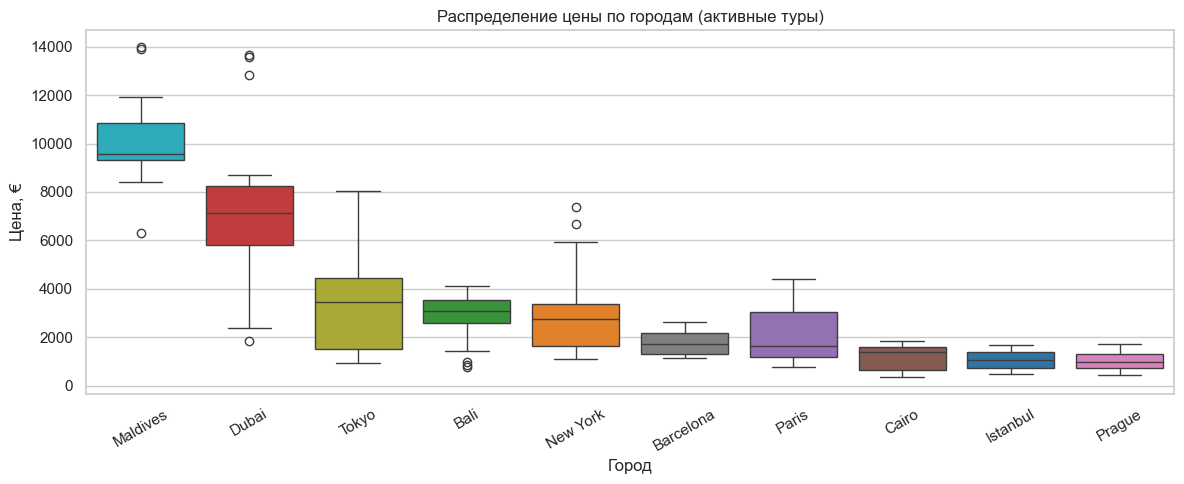

In [50]:
city_order = active.groupby("city_name")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(x="city_name", y="price", hue="city_name", data=active,
            order=city_order, palette="tab10", legend=False)
plt.title("Распределение цены по городам (активные туры)")
plt.xlabel("Город")
plt.ylabel("Цена, €")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(ARTIFACTS / "06_price_by_city.png")
plt.show()

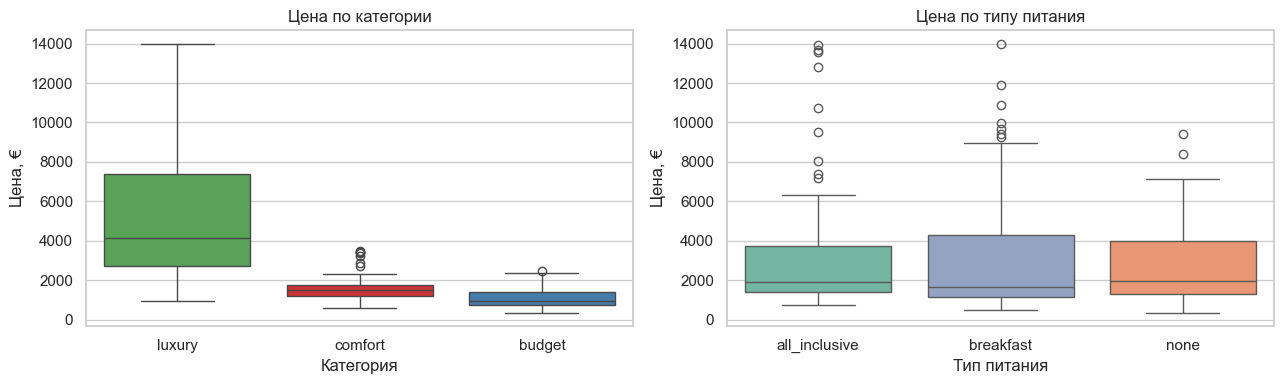

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x="category", y="price", hue="category", data=active,
            order=["luxury", "comfort", "budget"], palette="Set1", legend=False, ax=axes[0])
axes[0].set_title("Цена по категории")
axes[0].set_xlabel("Категория")
axes[0].set_ylabel("Цена, €")

sns.boxplot(x="meal_type", y="price", hue="meal_type", data=active,
            order=["all_inclusive", "breakfast", "none"], palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Цена по типу питания")
axes[1].set_xlabel("Тип питания")
axes[1].set_ylabel("Цена, €")

plt.tight_layout()
plt.savefig(ARTIFACTS / "07_price_by_category_meal.png")
plt.show()

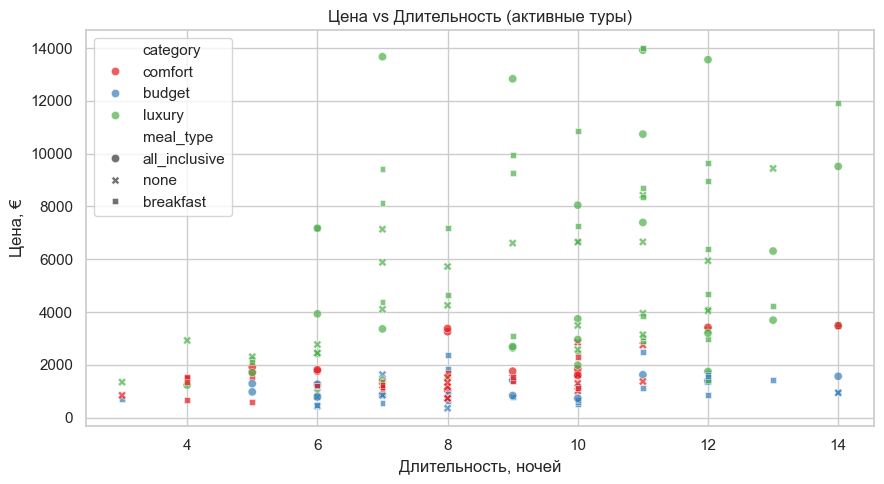

In [52]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x="duration_nights", y="price",
    hue="category", style="meal_type",
    data=active, alpha=0.7, palette="Set1"
)
plt.title("Цена vs Длительность (активные туры)")
plt.xlabel("Длительность, ночей")
plt.ylabel("Цена, €")
plt.tight_layout()
plt.savefig(ARTIFACTS / "08_price_vs_duration.png")
plt.show()

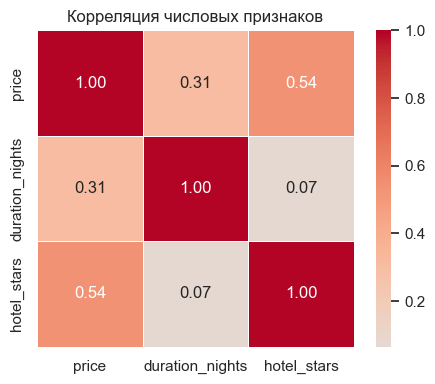

In [53]:
num_cols = ["price", "duration_nights", "hotel_stars"]
corr = active[num_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Корреляция числовых признаков")
plt.tight_layout()
plt.savefig(ARTIFACTS / "09_correlation.png")
plt.show()

**Наблюдения:**
- Мальдивы и Дубай – самые дорогие направления (медиана €9 587 и €7 137), Прага и Стамбул – самые доступные (€962 и €1 059).
- Категория `luxury` ожидаемо дороже, но разброс внутри категории большой – есть пересечение с `comfort`.
- `all_inclusive` в среднем дороже, но эффект сильно зависит от города (особенно Дубай и Мальдивы) — глобальное среднее искажено дорогими направлениями.
- Корреляция цены и звёздности отеля умеренно высокая (r=0.54), с длительностью – слабая (r=0.31): длинный тур не обязательно дорогой.

---
## 5. Групповая аналитика

In [54]:
city_stats = (
    active
    .groupby("city_name")
    .agg(
        count=("id", "count"),
        price_mean=("price", "mean"),
        price_median=("price", "median"),
        price_min=("price", "min"),
        price_max=("price", "max"),
        duration_mean=("duration_nights", "mean"),
    )
    .sort_values("price_median", ascending=False)
    .round(0)
)
city_stats

,count,price_mean,price_median,price_min,price_max,duration_mean
city_name,,,,,,
Maldives,14,10172.0,9587.0,6309.0,13992.0,11.0
Dubai,19,7188.0,7137.0,1835.0,13675.0,9.0
Tokyo,15,3619.0,3453.0,938.0,8049.0,12.0
Bali,22,2814.0,3082.0,784.0,4131.0,11.0
New York,13,3157.0,2745.0,1121.0,7394.0,10.0
Barcelona,22,1752.0,1702.0,1132.0,2641.0,7.0
Paris,20,2159.0,1640.0,783.0,4391.0,6.0
Cairo,14,1163.0,1401.0,353.0,1839.0,10.0
Istanbul,16,1049.0,1059.0,477.0,1676.0,8.0


In [55]:
(
    active
    .groupby(["city_name", "category"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
)

category,budget,comfort,luxury,total
city_name,,,,
Bali,5,0,17,22
Barcelona,1,13,8,22
Paris,7,5,8,20
Dubai,3,0,16,19
Istanbul,4,11,1,16
Prague,5,4,6,15
Tokyo,5,4,6,15
Cairo,6,5,3,14
Maldives,0,0,14,14


In [56]:
meal_city = (
    active
    .groupby(["city_name", "meal_type"])
    .agg(avg_price=("price", "mean"))
    .round(0)
    .unstack(fill_value=0)
)
meal_city

avg_price                  
meal_type all_inclusive breakfast    none
city_name                                
Bali             2752.0    2617.0  3296.0
Barcelona        1891.0    1771.0  1629.0
Cairo            1506.0    1003.0  1079.0
Dubai           11812.0    5816.0  6339.0
Istanbul          890.0    1016.0  1147.0
Maldives        10122.0   10506.0  8933.0
New York         4674.0    1439.0  3963.0
Paris            2421.0    1618.0  2588.0
Prague           1171.0     827.0   896.0
Tokyo            3591.0    3891.0  3247.0

**Наблюдение:** связь типа питания с ценой нелинейна и зависит от города. В Дубае и Мальдивах all-inclusive стоит значительно дороже (>€10 000), тогда как в Праге и Стамбуле разница между типами питания минимальна. Это означает, что `meal_type` несёт ценовой сигнал только в связке с `city_id` — изолированно признак слабее.

**Наблюдения:**
- Мальдивы и Дубай – самые дорогие направления, при этом у Дубая большой разброс цен (от бюджетных до ультра-люкс).
- Барселона и Бали – наиболее популярные направления по количеству активных туров (по 22), Париж – третий (20).
- Распределение категорий по городам **неравномерно**:
  - Мальдивы – только `luxury` (14 из 14), категории `budget` и `comfort` отсутствуют;
  - Бали и Дубай – `luxury` + `budget`, категория `comfort` отсутствует;
  - Барселона и Стамбул – преимущественно `comfort`;
  - Остальные города (Париж, Прага, Токио, Каир, Нью-Йорк) – представлены все три категории.
  - Это важно для рекомендательной системы: фильтрация по бюджету работает не во всех направлениях.

---
## 6. Отбор признаков для модели

**Признаки для модели** (только `status=active`):

- `city_id` – главный сигнал; определяет ценовой диапазон и стиль тура
- `category` – luxury / comfort / budget
- `hotel_stars` – числовой, r=0.54 с ценой
- `meal_type` – заметный вклад в цену (эффект нелинеен, зависит от города)
- `price` → `log1p(price)` – устраняет правый скос (skewness 2.x → ~0.x)
- `duration_nights` – слабый сигнал (r=0.31), но оставляем
- `description` – текст для TF-IDF / эмбеддингов

**Отбрасываем** как дублирующие или нерелевантные:
`name`, `city_name`, `country`, `hotel_id`, `hotel_name`, `photo_url`, `id`

`status` — отброшен как константа: после фильтрации датасета до `status=active` колонка принимает единственное значение и не несёт информации.

`start_date` отброшен: сезонные паттерны наблюдаются (раздел 3), но в content-based модели без пользовательских предпочтений дата тура не несёт сигнала схожести. Потенциальное использование — жёсткий фильтр по доступным датам на уровне сервиса.

---
## 7. Итоговые выводы

1. **`city_id` – главный сигнал для рекомендаций:** определяет ценовой диапазон и стиль тура. Цена – наиболее информативный числовой признак: коррелирует со звёздностью отеля (r=0.54) и категорией, но сама является следствием города. Распределение правосторонне скошено – при обучении использовать `log1p(price)`.

2. **Активных туров 85%:** для рекомендательной системы фильтровать только `status=active`.

3. **Три сильных сигнала для content-based рекомендаций:** город (`city_id`), категория (`category`), звёздность (`hotel_stars`).

4. **Текстовые описания (`description`)** пригодны для TF-IDF / эмбеддингов – дополнительный сигнал схожести.

5. **Следующий шаг:** `exp02_baseline.ipynb` – построить и сравнить модели: popularity-baseline, content-based на структурированных признаках, content-based с TF-IDF на описаниях.